# Notebook métricas de evaluación con RR Lyrae

Basado en Machine learning for physics and Astronomy, Viviana Acquaviva (2023)

En esta actividad trabajaremos con un problema de clasificación binaria: distinguir estrellas **RR Lyrae** de otras estrellas a partir de sus colores fotométricos.

### Los objetivos son
- entrenar un clasificador simple
- evaluar su rendimiento con distintas métricas
- interpretar una matriz de confusión
- comparar accuracy con precision, recall y F1
- discutir qué métrica conviene según el objetivo científico

### Contexto
Las RR Lyrae son estrellas variables pulsantes muy importantes en astronomía. En un catálogo grande, un clasificador puede ayudarnos a encontrar candidatas RR Lyrae, pero no basta con mirar solo el accuracy.


### Descripción de los datos
El set de datos que usará para esta tarea es sobre estrellas. Las características son colores en distintos filtros del [sistema ugriz de SDSS](https://www.physics.unlv.edu/~jeffery/astro/photometry/photometry_sdss.html), que son un indicador si la estrella emite luz más azul, verde, amarilla o roja. Queremos predecir a partir de estas características si la estrella es un tipo especial de estrella llamada variable RR Lyrae.

- Las características son los colores u-g, g-r, r-i, i-z
- El target es 0 (no RRLyrae) y 1 (RRLyrae)


In [1]:
import pandas as pd
import numpy as np

import sklearn.tree
from sklearn.tree import DecisionTreeClassifier #modelo
from sklearn.tree import plot_tree #visualizacion arbol
from sklearn.model_selection import train_test_split
from sklearn import metrics #métricas
from sklearn.model_selection import cross_val_predict, cross_val_score, cross_validate #validación cruzada
from sklearn.model_selection import KFold, StratifiedKFold #validación cruzada

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay #matriz de confusión


from scipy import stats

In [2]:
from io import StringIO
from IPython.display import Image
#import pydotplus
from sklearn.tree import export_graphviz

In [3]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

font = {'size': 8}

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=8)
matplotlib.rc('ytick', labelsize=8)
matplotlib.rcParams['figure.dpi'] = 300

pd.set_option('display.max_columns', 100) #Para poder visualizar todas las columnas del dataframe
pd.set_option('display.max_colwidth', 100)

## Primer paso: exploración de los datos

Siempre es importante hacer una análisis exploratorio del conjunto de datos que trabajaremos. Leemos el archivo como un dataframe y extraemos información básica

In [4]:
from google.colab import drive
drive.mount('/content/drive')

ModuleNotFoundError: No module named 'google'

In [5]:

#cargamos los datos como arreglos numpy
features= np.loadtxt("RRLyrae_features_small.txt", delimiter=',')
targets= np.loadtxt("RRLyrae_labels_small.txt", delimiter=',')


In [6]:
columnas = ["u-g", "g-r", "r-i", "i-z"]
df = pd.DataFrame(features, columns=columnas)
df["RR_Lyrae"] = targets.astype(int)

df.head()

,u-g,g-r,r-i,i-z,RR_Lyrae
0,0.311,0.714,0.093,0.204,0
1,0.332,0.965,0.122,0.032,0
2,0.394,1.019,0.147,0.096,0
3,0.285,0.865,0.120,0.039,0
4,0.386,0.977,0.181,0.080,0


In [20]:
Estrellas = df['RR_Lyrae'].value_counts().head()

print("Cantidad de Estrellas (0) y Estrellas RR Lyrae (1):")
print(Estrellas)

Cantidad de Estrellas (0) y Estrellas RR Lyrae (1):
RR_Lyrae
0    2000
1     483
Name: count, dtype: int64


### Preguntas
1. ¿Este es un problema de clasificación o regresión?
2. ¿Es un problema binario o multiclase?
3. ¿Qué representa la variable objetivo?
4. ¿Las clases están balanceadas o desbalanceadas?
5. ¿Por qué esto podría ser importante al elegir una métrica de evaluación?

**RESPUESTAS:**
1. Es un problema de clasificación. El objetivo es asignar cada estrella a una categoría discreta.
2. Es un problema binario, solo existen dos resultados posibles para la predicción; la clase positiva (es RR Lyrae) y la clase negativa (cualquier otra estrella).
3. Representa el tipo de estrella, indicando mediante una etiqueta (1 o 0) si la estrella observada pertenece al grupo de las RR Lyrae.
4. Están desbalanceadas. De un total de 2483 estrellas, solo 483 pertenecen a la clase de interés, mientras que la gran mayoría (más o menos un 80%) corresponde a estrellas no RR Lyrae.
5. Porque métricas como el accuracy se vuelven engañosas, por ejemplo, un modelo que prediga siempre "no RR Lyrae" tendría 80% de precisión sin aprender nada. Es mejor usar métricas como F1, Precision o Recall para medir bien el desempeño en la clase más pequeña.

#### Haga una visualización de sólo dos columnas para revisar los colores de las RR Lyrae y las no RRLyrae

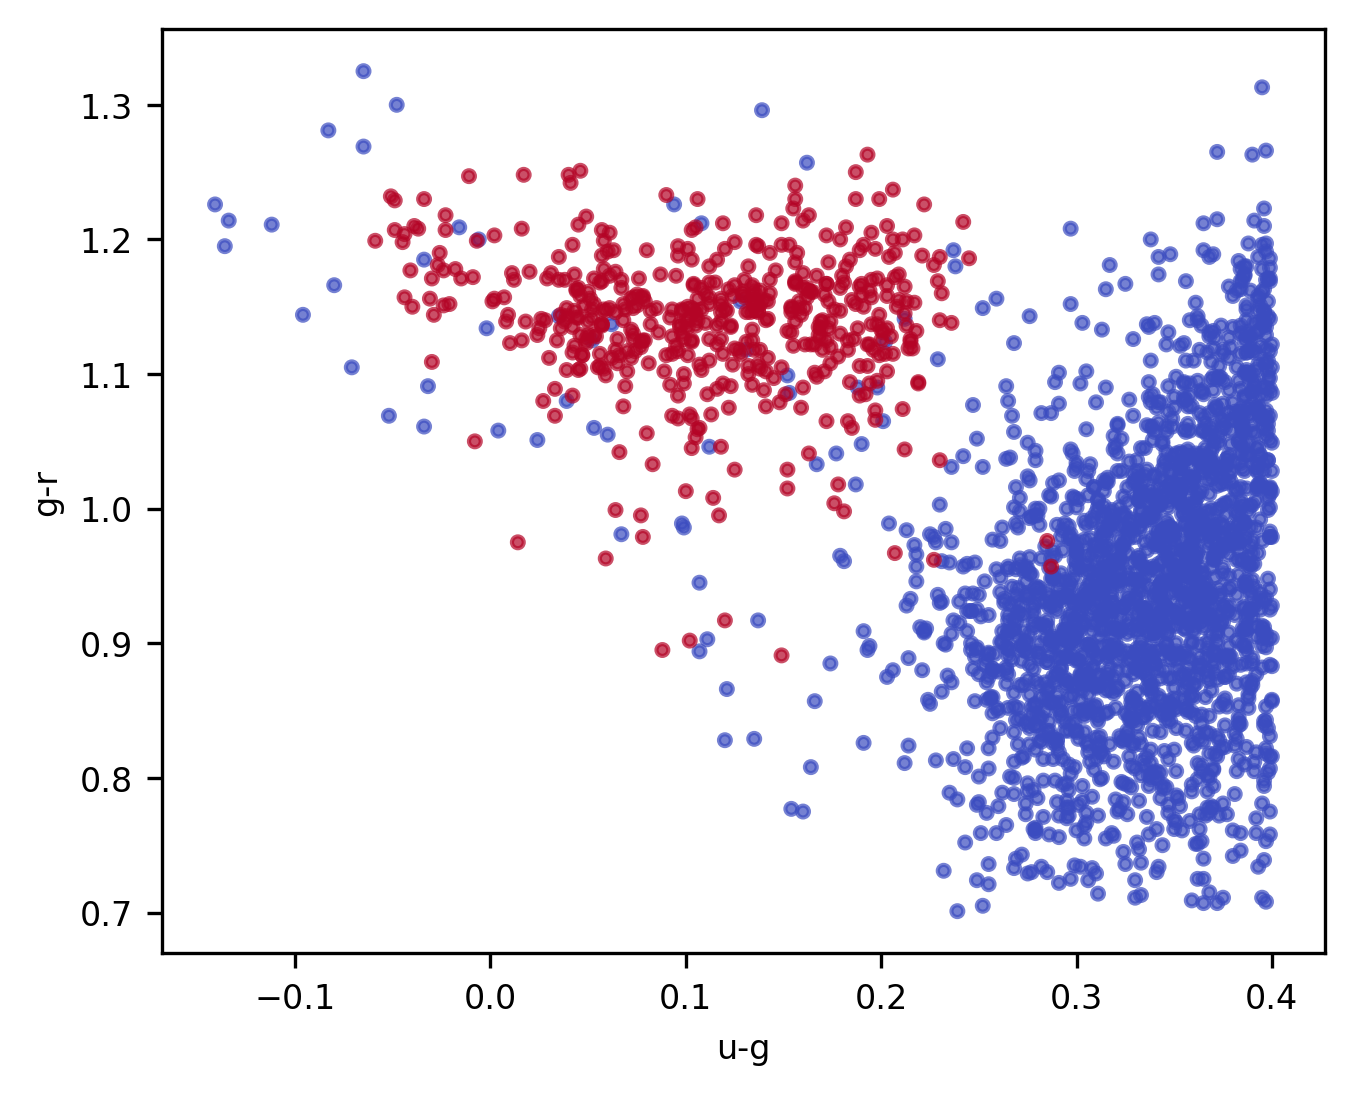

In [7]:
#complete la celda
plt.figure(figsize=(5,4))

sc=plt.scatter(x=df['u-g'], y=df['g-r'], c=df['RR_Lyrae'], cmap='coolwarm', s=8, alpha=0.7)
plt.xlabel('u-g')
plt.ylabel('g-r')
plt.show()

### Pregunta
1. ¿Se observan regiones donde las clases parecen separarse?
2. A simple vista, ¿esperarías que un árbol de decisión funcione razonablemente bien?

**RESPUESTAS:**
1. Si pareciera que se separan. El grupo rojo (Lyrae) se agrupa hacia un g-r mas alto (>1) y u-g bajo (<0.25) a diferencia del grupo azul (no Lyrae) que justamente se concentra en un u-g mas alto, 0.3 a 0.4 y más abajo en el eje g-r. Aun así, hay valores, aunque son pocos, de no Lyrae distribuidos por todo el plot. 
2. Esperaria que si, ya que como mencione, hay una region particularmente dominada por estrellas RR Lyrae. Por lo que un árbol de decisiones debería de tener un accuracy razonablemente bueno frente a estos datos. 

#### Separe los datos en entrenamiento y prueba

In [8]:
X = df[["u-g", "g-r", "r-i", "i-z"]]
y = df["RR_Lyrae"]

In [9]:
#complete la celda
X_train, X_test, y_train, y_test =train_test_split(X,y,test_size=0.3, random_state=42)

In [10]:
X_train.shape

(1738, 4)

### Antes de continuar

Las clases en este problema no están perfectamente balanceadas.

Piense en la forma en que podríamos separar los datos en entrenamiento y prueba, y responda:

1. ¿Qué problema podría ocurrir si hacemos la partición de manera completamente aleatoria, sin preocuparnos por la proporción de clases?
2. ¿Por qué eso podría afectar la evaluación del modelo?
3. ¿Qué tipo de precaución cree que sería razonable tomar al construir los conjuntos de entrenamiento y prueba en este caso?

**RESPUESTAS:**
1. Podria ocurrir de que el modelo se entrene solo con datos no RR Lyrae, por lo que, luego con los datos de prueba concluya que ninguno es RR Lyrae, o viceversa, que entrene solo con datos que si son y luego concluya que todos los datos son estrellas variables pulsantes. 
2. Al no entrenar con una submuestra representativa de la muestra total el modelo, se generarian muchos falsos positivos o muchos falsos negativos, generando un mal accuracy.
3. De algún modo exigir que tome el mismo porcentaje de las estrellas no variabes pulsantes, como tambien de las variables pulsantes. De este modo quedan bien representadas y el modelo se entrena de buena forma para ambas poblaciones. 

#### Ahora entrenaremos un árbol de decisión (modelo base)

In [11]:
model_tree = DecisionTreeClassifier(random_state=42)
model_tree.fit(X_train, y_train)
#entrene el modelo y genere las predicciones
y_pred=model_tree.predict(X_test)


#### Visualicemos el árbol

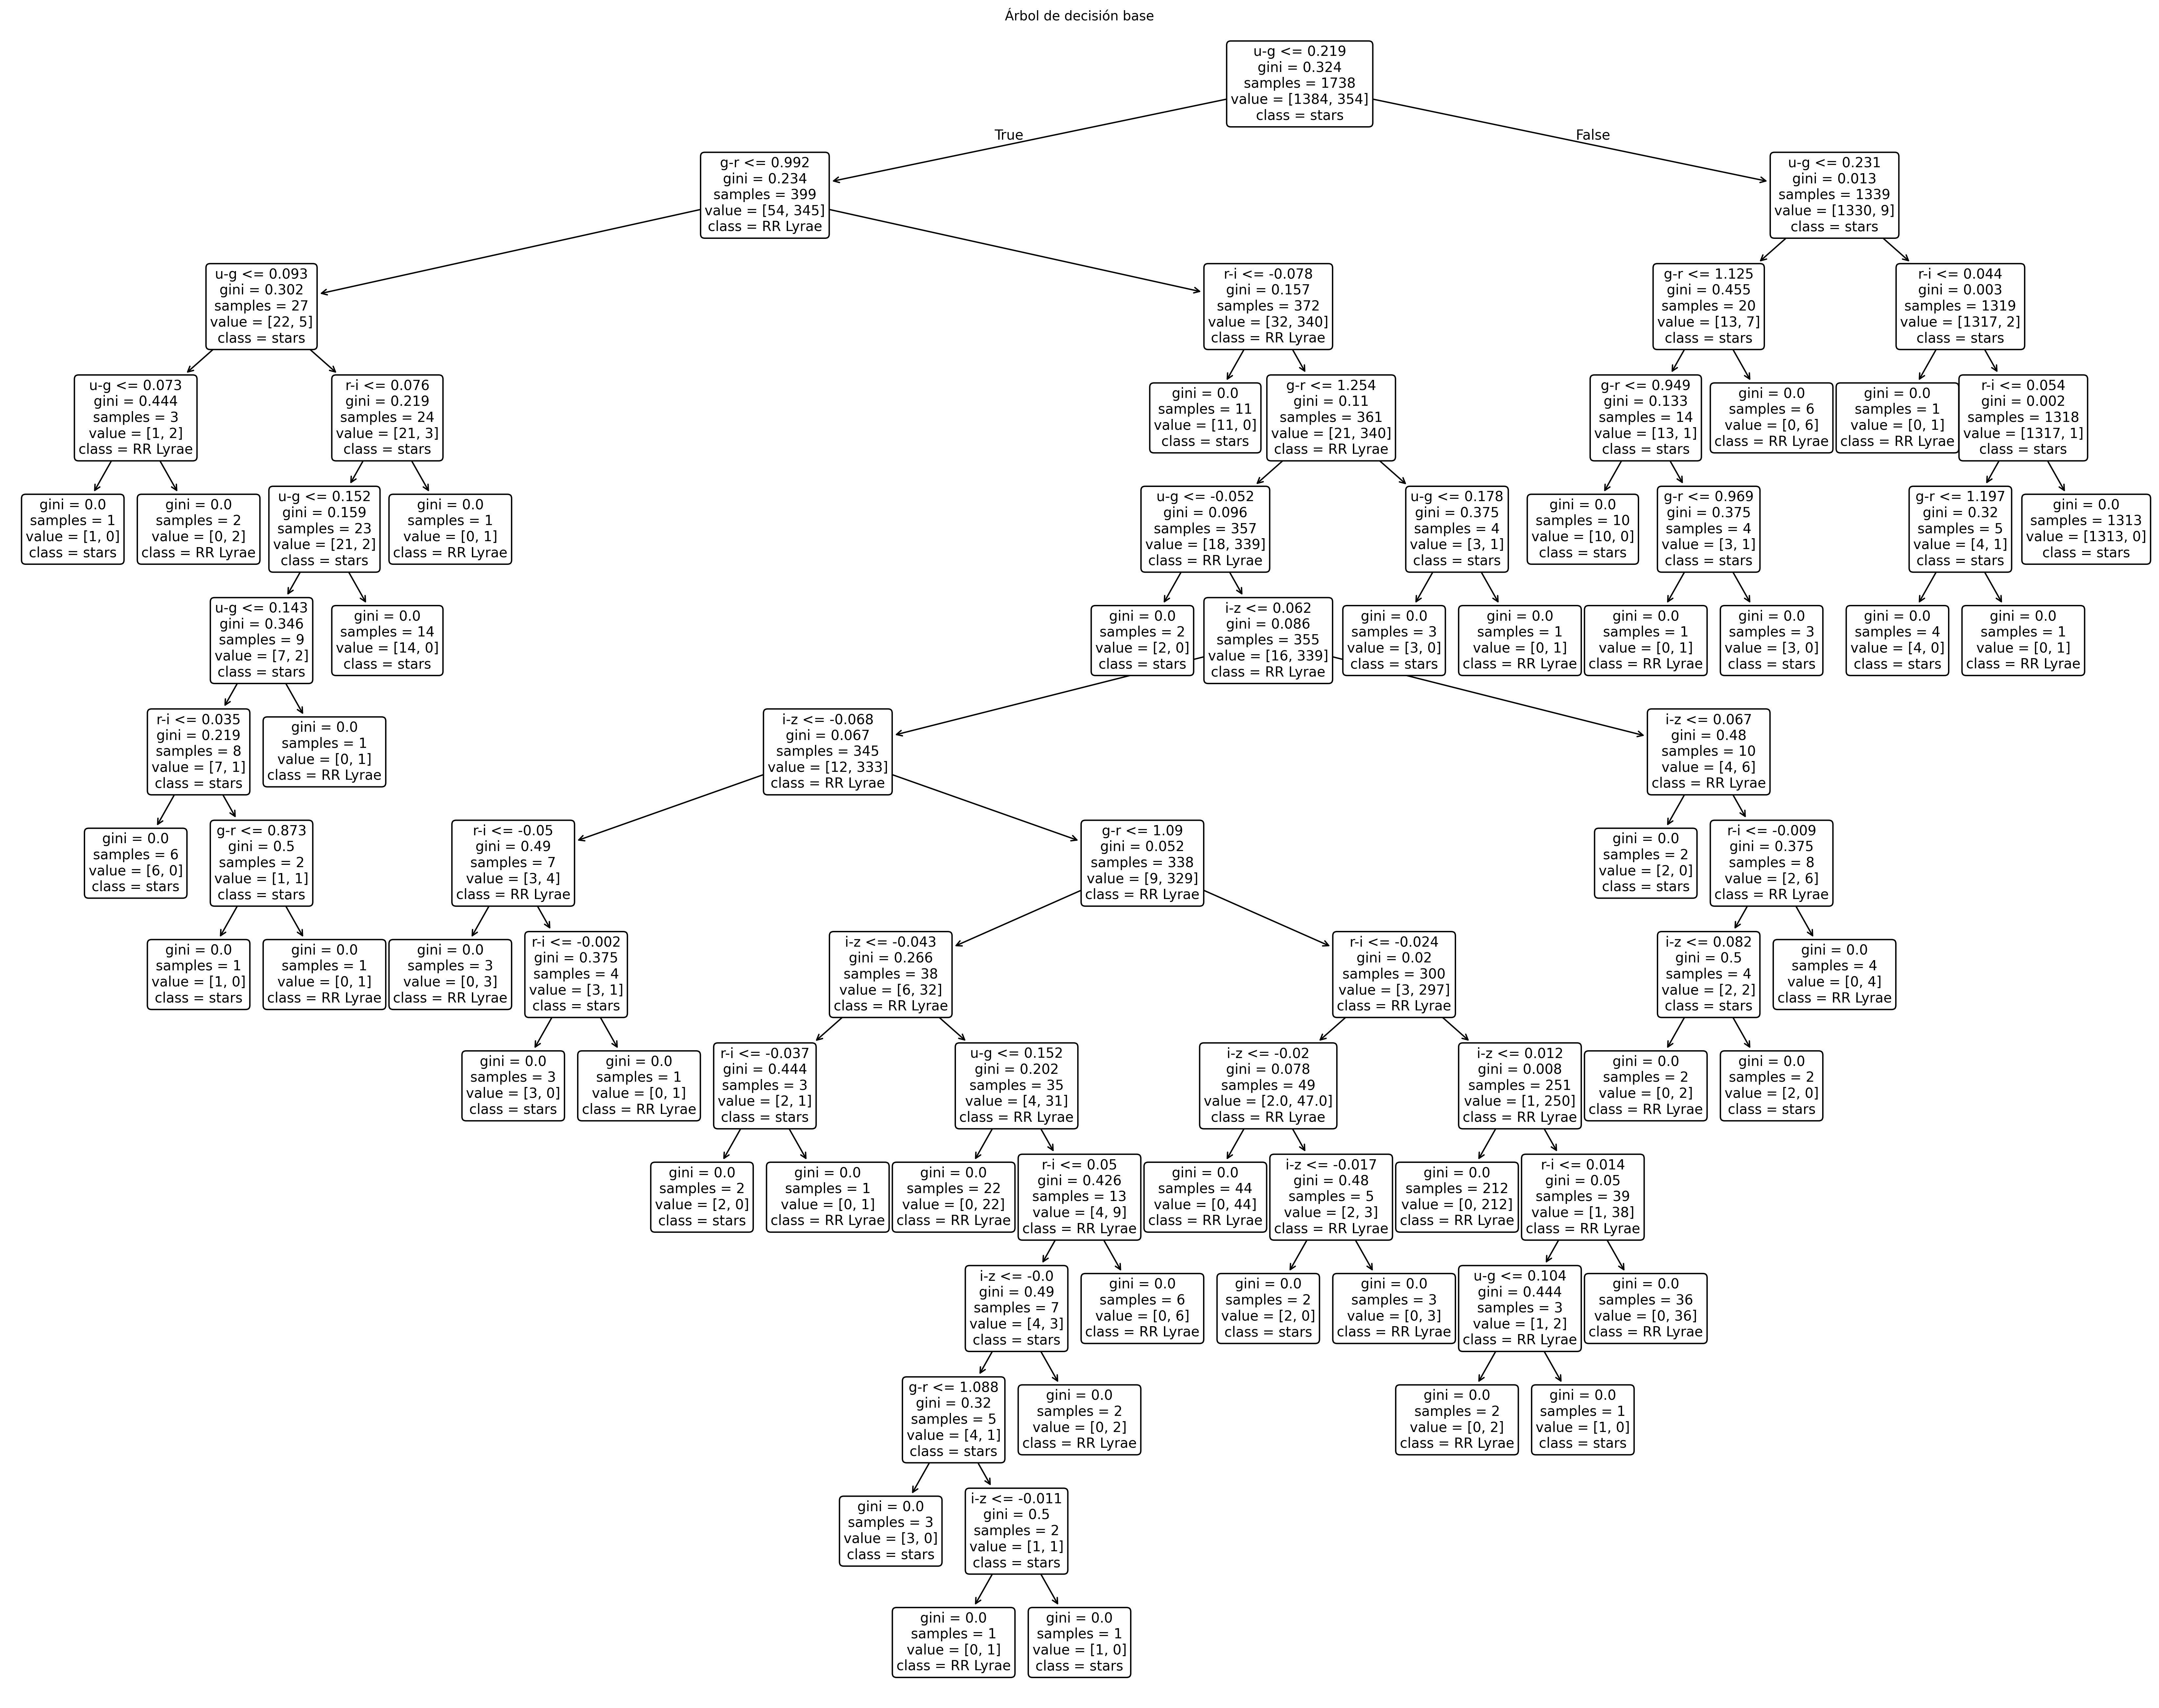

In [12]:
plt.figure(figsize=(28,22))

plot_tree(
    model_tree,
    feature_names=X.columns,
    class_names=["stars", "RR Lyrae"],
    filled=False,
    rounded=True,
    #max_depth=3,
    fontsize=10
)

plt.title("Árbol de decisión base")
plt.show()

In [13]:
# Recordatorio: Las características siempre se permutan aleatoriamente en cada división.
# Por lo tanto, la mejor división encontrada puede variar, incluso con los mismos datos
# de entrenamiento y max_features=n_features, si la mejora del criterio es idéntica
# para varias divisiones enumeradas durante la búsqueda de la mejor división.
# Para obtener un comportamiento determinista durante el ajuste, random_state debe estar fijo.

dot_data = StringIO()

export_graphviz(
    model_tree,
    out_file=dot_data,
    feature_names=['u-g', 'g-r', 'r-i', 'i-z'],
    class_names=['stars', 'RR Lyrae'],
    filled=True,
    rounded=True,
    special_characters=True
)

graph = pydotplus.graph_from_dot_data(dot_data.getvalue().replace("\n", ""))
nodes = graph.get_node_list()

for node in nodes:
    if node.get_label() and 'value = [' in node.get_label():

        values = [float(ii) for ii in node.get_label().split('value = [')[1].split(']')[0].split(',')]
        values = [int(255 * v / sum(values)) for v in values]

        if values[0] > values[1]:
            alpha = int(values[0] - values[1])
            alpha = '{:02x}'.format(alpha)
            color = '#9ecae1' + str(alpha)   # turquesa
        else:
            alpha = int(values[1] - values[0])
            alpha = '{:02x}'.format(alpha)
            color = '#756bb1' + str(alpha)   # magenta

        node.set_fillcolor(color)

Image(graph.create_png())

NameError: name 'pydotplus' is not defined

### Preguntas

Observe la estructura del árbol y responda brevemente:

1. ¿El árbol parece muy simple o bastante complejo? Justifique a partir del número de niveles o divisiones.
2. ¿Qué desventaja podría tener un árbol demasiado grande en un problema como este?

**RESPUESTAS:**
1. El árbol es bastante complejo, ya que hay más de 12 niveles o más de 12 divisiones más o menos, llegando en varios casos a coeficientes de gini igual a cero, lo cual puede ser un poco peligroso, ya que las clasificaciones se vuelven muy estrictas y puede generar un overfitting. 
2. Como ya mencioné se pueden generar sobreajustes, o que el modelo no sea bueno frente a los valores de prueba. Además, la alta complejidad dificulta la interpretación del arbol de decisiones, visualmente tiene mucha información.

#### Miremos las métricas accuracy para set de entrenamiento y prueba

In [14]:
print(metrics.accuracy_score(y_train, model_tree.predict(X_train))) #train score

print(metrics.accuracy_score(y_test, model_tree.predict(X_test))) #test score

1.0
0.9651006711409396


#### Otras métricas

In [15]:
print("Precision:", metrics.precision_score(y_test, y_pred))
print("Recall   :", metrics.recall_score(y_test, y_pred))
print("F1-score :", metrics.f1_score(y_test, y_pred))

Precision: 0.8759124087591241
Recall   : 0.9302325581395349
F1-score : 0.9022556390977443


In [16]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[599,  17],
       [  9, 120]])

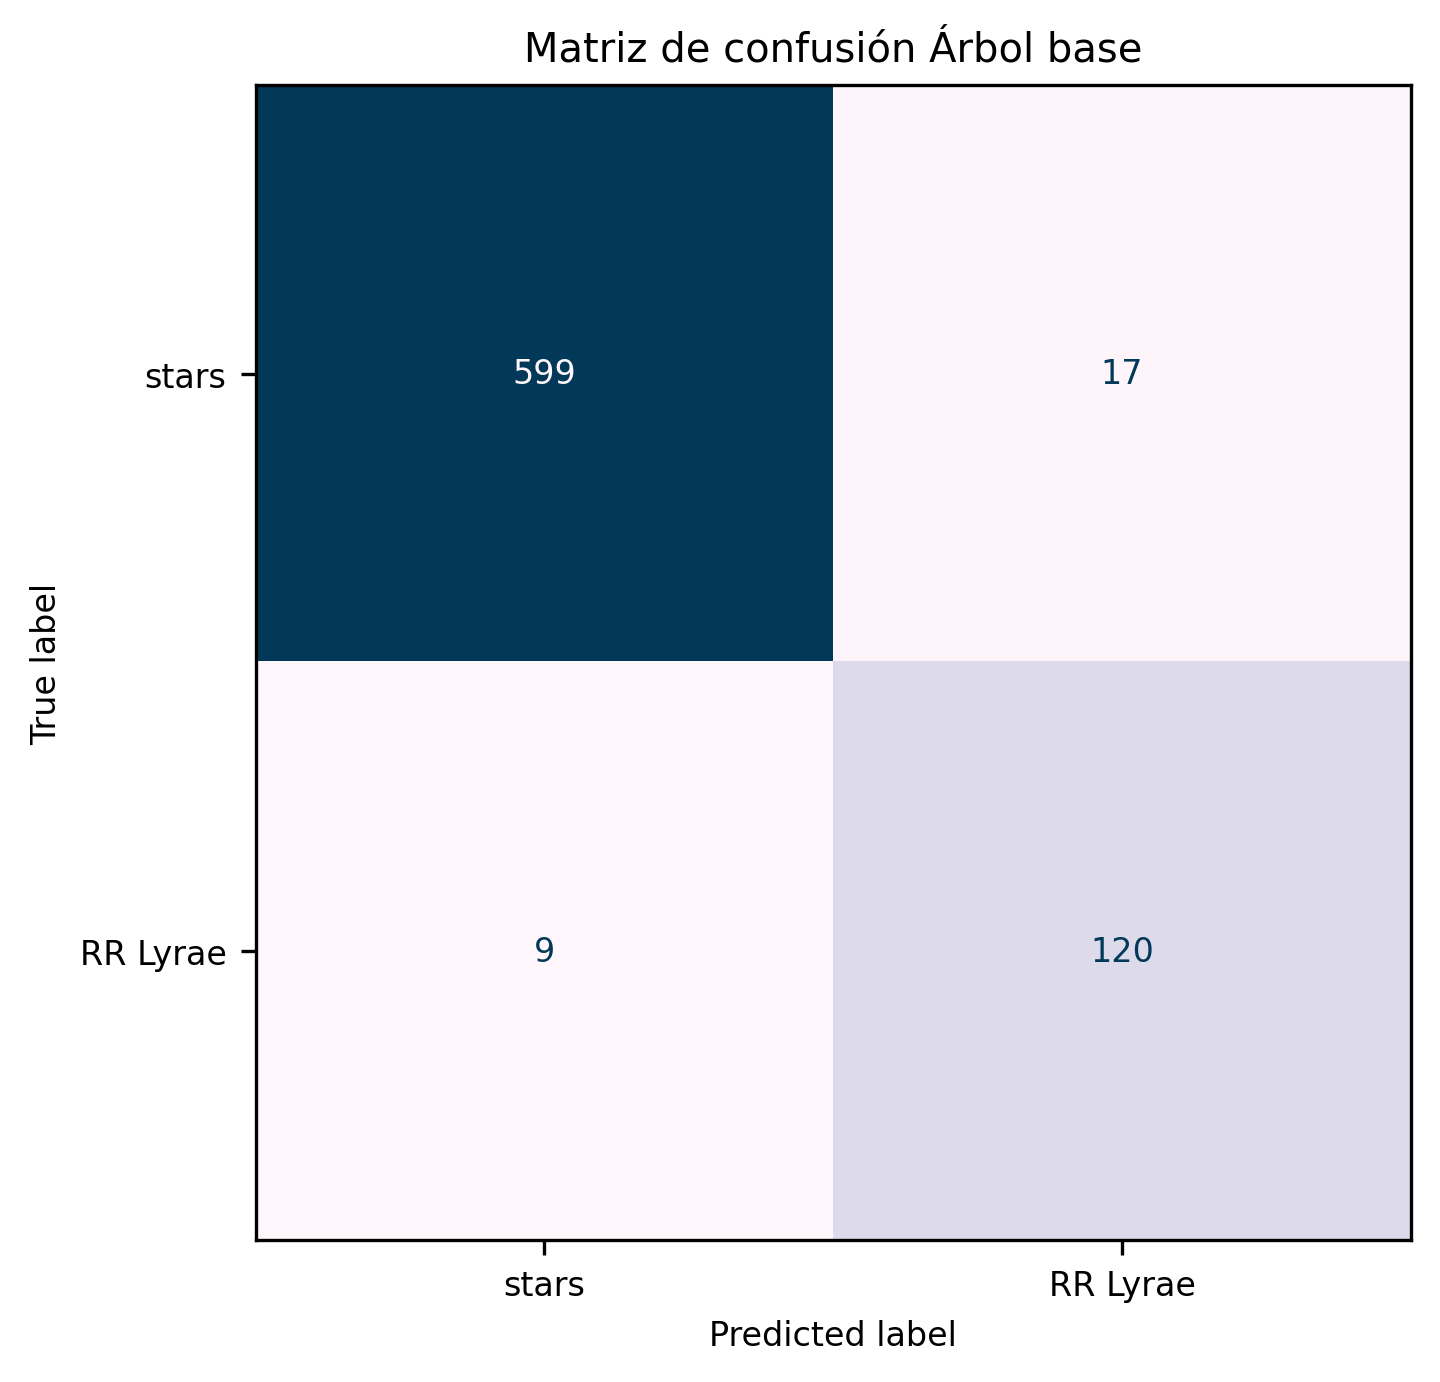

In [17]:
fig, ax = plt.subplots(figsize=(5,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["stars", "RR Lyrae"])
disp.plot(cmap="PuBu", ax=ax, colorbar=False)

plt.title("Matriz de confusión Árbol base")
plt.show()

#### A partir de la matriz de confusión obtenida:
1.  Identifique los valores de:
   - verdaderos positivos (TP)
   - verdaderos negativos (TN)
   - falsos positivos (FP)
   - falsos negativos (FN)
2. Calcule las métricas "a mano"



In [22]:
print('Los verdaderos positivos son:', 120)
print('Los verdaderos negativos son:', 599)
print('Los falsos positivos son:', 17)
print('Los falsos negativos son:', 9)

Los verdaderos positivos son: 120
Los verdaderos negativos son: 599
Los falsos positivos son: 17
Los falsos negativos son: 9


In [25]:
TP = 120
FP = 17
FN = 9
TN = 599

precision = TP / (TP + FP)

recall = TP / (TP + FN)

f1_score = 2 * (precision * recall) / (precision + recall)

print(f"Precisión: {precision:.5f}")  
print(f"Recall:    {recall:.5f}")    
print(f"F1-Score:  {f1_score:.5f}") 

Precisión: 0.87591
Recall:    0.93023
F1-Score:  0.90226


### Preguntas
1. Explique con sus palabras qué significa, en este problema:
   - un falso positivo
   - un falso negativo

2. Si el objetivo científico fuera encontrar la mayor cantidad posible de RR Lyrae, ¿qué tipo de error preocuparía más?

3. Si el objetivo fuera construir una muestra final más limpia, ¿qué tipo de error preocuparía más?

**RESPUESTAS:**
1. Falso positivo: Clasificar por error una estrella normal como si fuera una RR Lyrae, predecir que es una RR Lyrae cuando en realidad no lo es.
Falso negativo: Dejar pasar una verdadera estrella RR Lyrae y clasificarla como estrella normal, predecir como una estrella cualquiera cuando en verdad es una RR Lyrae.
2. Preocuparían más los falsos negativos. Se quiere minimizar las RR Lyrae que se pierden para maximizar la cantidad detectada, por lo cual habría que priorizar el recall.
3. Este es el caso opuesto al de recién, preocuparían más los falsos positivos. Queremos evitar colar estrellas normales por error dentro del catálogo final de RR Lyrae, por lo tanto hay que priorizar la precision.

#### Todo parece funcionar bien, pero sólo hicimos un split. Necesitamos que el resultados sea robusto. Para esto, implementaremos Cross-validation usando [k-fold](https://scikit--learn-org.translate.goog/stable/modules/generated/sklearn.model_selection.KFold.html?_x_tr_sl=en&_x_tr_tl=es&_x_tr_hl=es&_x_tr_pto=tc)

In [26]:
# Esta es la versión estándar. Importante: no baraja los datos, por lo que si tus
# ejemplos positivos están todos al principio o al final, podría llevar a resultados
# desastrosos.

cv1 = KFold(n_splits = 5)

#Esta es la versión 2: se ha añadido el barajado (¡recomendado!)

cv2 = KFold(shuffle = True, n_splits = 5, random_state=5)

# LA ESTRATIFICACIÓN asegura que las distribuciones de clases en cada división se
# asemejen a las del conjunto de datos completo.

cv3 = StratifiedKFold(shuffle = True, n_splits = 5, random_state=5)


### Efecto de la estratificación: veamos el conteo de clases en cada conjunto de divisiones.

In [ ]:
cv1.split(X, y)

<generator object _BaseKFold.split at 0x755741141030>

In [28]:
for train, test in cv1.split(X, y):
    print('train -  {}   |   test -  {}'.format(
        np.bincount(y.loc[train]), np.bincount(y.loc[test])))

train -  [1503  483]   |   test -  [497]
train -  [1503  483]   |   test -  [497]
train -  [1503  483]   |   test -  [497]
train -  [1504  483]   |   test -  [496]
train -  [1987]   |   test -  [ 13 483]


In [29]:
for train, test in cv2.split(X, y):
     print('train -  {}   |   test -  {}'.format(
         np.bincount(y.loc[train]), np.bincount(y.loc[test])))

train -  [1600  386]   |   test -  [400  97]
train -  [1610  376]   |   test -  [390 107]
train -  [1587  399]   |   test -  [413  84]
train -  [1599  388]   |   test -  [401  95]
train -  [1604  383]   |   test -  [396 100]


In [30]:
for train, test in cv3.split(X, y):
     print('train -  {}   |   test -  {}'.format(
         np.bincount(y.loc[train]), np.bincount(y.loc[test])))

train -  [1600  386]   |   test -  [400  97]
train -  [1600  386]   |   test -  [400  97]
train -  [1600  386]   |   test -  [400  97]
train -  [1600  387]   |   test -  [400  96]
train -  [1600  387]   |   test -  [400  96]


### La función [`cross_validate`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_validate.html#sklearn.model_selection.cross_validate) proporciona los puntajes (especificados por el parámetro de evaluación elegido), en forma de diccionario.

In [31]:
scores1 = cross_validate(DecisionTreeClassifier(), X, y, cv = cv1, scoring = 'accuracy')

scores2 = cross_validate(DecisionTreeClassifier(), X, y, cv = cv2, scoring = 'accuracy')

scores3 = cross_validate(DecisionTreeClassifier(), X, y, cv = cv3, scoring = 'accuracy')

In [32]:
scores1

{'fit_time': array([0.01633048, 0.01532078, 0.01151037, 0.01245928, 0.00496769]),
 'score_time': array([0.00636768, 0.00511646, 0.00545382, 0.00605679, 0.00497627]),
 'test_score': array([0.98390342, 0.98390342, 0.96981891, 0.96774194, 0.02620968])}

In [33]:
scores2


{'fit_time': array([0.01044226, 0.01319361, 0.01457119, 0.01002645, 0.01055098]),
 'score_time': array([0.00670266, 0.00507283, 0.00510311, 0.00465155, 0.00448442]),
 'test_score': array([0.9637827 , 0.96579477, 0.98390342, 0.95967742, 0.94959677])}

In [34]:
scores3

{'fit_time': array([0.00951791, 0.00723839, 0.00688982, 0.00745702, 0.00712514]),
 'score_time': array([0.00448966, 0.00333309, 0.00295067, 0.0029881 , 0.00351453]),
 'test_score': array([0.9778672 , 0.96780684, 0.96780684, 0.98185484, 0.95967742])}

Solo nos interesa el 'test_score'

#### Calculamos el promedio y $\sigma$

In [35]:
print("{:.3f}".format(scores1['test_score'].mean()), "{:.3f}".format(scores1['test_score'].std()))

0.786 0.380


In [36]:
print("{:.3f}".format(scores2['test_score'].mean()), "{:.3f}".format(scores2['test_score'].std()))

0.965 0.011


In [37]:
print("{:.3f}".format(scores3['test_score'].mean()), "{:.3f}".format(scores3['test_score'].std()))

0.971 0.008


La validación cruzada sin barajar (`cv1`) produce un resultado muy inestable, con una desviación estándar extremadamente alta. Esto ocurre porque los datos están ordenados por clase, de modo que algunos folds no representan bien el problema completo.

Al activar el barajado (`cv2`), el rendimiento mejora drásticamente y la dispersión disminuye. Sin embargo, el método que resulta más apropiado para este problema es `StratifiedKFold` (`cv3`), ya que además de mezclar los datos, conserva aproximadamente la proporción de clases en cada fold.

En problemas de clasificación desbalanceada, esta última estrategia suele ser la más recomendable.

In [38]:
scores1 = cross_validate(DecisionTreeClassifier(random_state=1), X,y, cv = cv1, scoring = 'recall')

scores2 = cross_validate(DecisionTreeClassifier(random_state=1), X,y, cv = cv2, scoring = 'recall')

scores3 = cross_validate(DecisionTreeClassifier(random_state=1), X,y, cv = cv3, scoring = 'recall')

/home/fabian/Documentos/Universidad/Computacional_I/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/fabian/Documentos/Universidad/Computacional_I/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/fabian/Documentos/Universidad/Computacional_I/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, 

In [39]:
print("{:.3f}".format(scores1['test_score'].mean()), "{:.3f}".format(scores1['test_score'].std()))
print("{:.3f}".format(scores2['test_score'].mean()), "{:.3f}".format(scores2['test_score'].std()))
print("{:.3f}".format(scores3['test_score'].mean()), "{:.3f}".format(scores3['test_score'].std()))

nan nan
0.903 0.016
0.925 0.019


### ¿Por qué aparece este warning?

En algunos folds generados por `KFold` sin barajado, el conjunto de prueba contiene solo ejemplos de una clase. En ese caso, el recall de la clase positiva (RR Lyrae) no puede calcularse, porque no hay positivos reales en ese fold.

Esto muestra que una estrategia de partición inadecuada puede hacer que la evaluación sea inestable, engañosa o incluso inválida.

#### También extraeremos los train scores, que nos servirán cuando estemos diagnosticando el modelo a través de bias vs variance.¶

In [40]:
scores1 = cross_validate(DecisionTreeClassifier(), X,y, cv = cv1, scoring = 'recall', \
                         return_train_score = True)

scores2 = cross_validate(DecisionTreeClassifier(), X,y, cv = cv2, scoring = 'recall', \
                         return_train_score = True)

scores3 = cross_validate(DecisionTreeClassifier(), X,y, cv = cv3, scoring = 'recall',
                         return_train_score = True)

/home/fabian/Documentos/Universidad/Computacional_I/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/fabian/Documentos/Universidad/Computacional_I/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/fabian/Documentos/Universidad/Computacional_I/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, 

In [41]:
print("{:.3f}".format(scores1['test_score'].mean()), "{:.3f}".format(scores1['train_score'].mean()))
print("{:.3f}".format(scores2['test_score'].mean()), "{:.3f}".format(scores2['train_score'].mean()))
print("{:.3f}".format(scores3['test_score'].mean()), "{:.3f}".format(scores3['train_score'].mean()))

nan nan
0.909 1.000
0.921 1.000


### La función  `cross_validate` es útil para calcular el puntaje, pero no produce etiquetas predichas.

#### Estas pueden obtenerse utilizando la función [`cross_val_predict`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_predict.html), que guarda las predicciones para cada uno de los k-folds de prueba y las compila juntas.


In [42]:
model1 = DecisionTreeClassifier(random_state = 3)

y_cv3 = cross_val_predict(model1, X,y, cv = cv3)
# Estas son las predicciones,
# y son independientes del parámetro de evaluación

In [43]:
metrics.confusion_matrix(targets,y_cv3)

array([[1955,   45],
       [  33,  450]])

### Sin embargo, las cosas pueden cambiar si uso un esquema de validación cruzada diferente:

In [44]:
model2 = DecisionTreeClassifier(random_state = 3)

y_cv2 = cross_val_predict(model2, X,y, cv = cv2)

In [45]:
np.sum(y_cv3-y_cv2)

np.int64(10)

In [46]:
np.sum(y_cv2)

np.int64(485)

In [47]:
np.sum(y_cv3 != y_cv2) #comparando las predicciones

np.int64(52)

In [48]:
metrics.confusion_matrix(targets,y_cv2)

array([[1955,   45],
       [  43,  440]])

In [49]:
metrics.confusion_matrix(targets,y_cv3)

array([[1955,   45],
       [  33,  450]])

In [50]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, title, X, y, ylim=None, cv=5,
                        n_jobs=-1, train_sizes=np.linspace(0.2, 1.0, 5), scoring = 'accuracy'):
    """
    Generate a simple plot of the test and training learning curve.

    Parameters
    ----------
    estimator : object type that implements the "fit" and "predict" methods
        An object of that type which is cloned for each validation.

    title : string
        Title for the chart.

    X : array-like, shape (n_samples, n_features)
        Training vector, where n_samples is the number of samples and
        n_features is the number of features.

    y : array-like, shape (n_samples) or (n_samples, n_features), optional
        Target relative to X for classification or regression;
        None for unsupervised learning.

    ylim : tuple, shape (ymin, ymax), optional
        Defines minimum and maximum yvalues plotted.

    cv : int, cross-validation generator or an iterable, optional
        Determines the cross-validation splitting strategy.
        Possible inputs for cv are:
          - None, to use the default 3-fold cross-validation,
          - integer, to specify the number of folds.
          - :term:`CV splitter`,
          - An iterable yielding (train, test) splits as arrays of indices.

        For integer/None inputs, if ``y`` is binary or multiclass,
        :class:`StratifiedKFold` used. If the estimator is not a classifier
        or if ``y`` is neither binary nor multiclass, :class:`KFold` is used.

        Refer :ref:`User Guide <cross_validation>` for the various
        cross-validators that can be used here.

    n_jobs : int or None, optional (default=None)
        Number of jobs to run in parallel.
        ``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.
        ``-1`` means using all processors. See :term:`Glossary <n_jobs>`
        for more details.

    train_sizes : array-like, shape (n_ticks,), dtype float or int
        Relative or absolute numbers of training examples that will be used to
        generate the learning curve. If the dtype is float, it is regarded as a
        fraction of the maximum size of the training set (that is determined
        by the selected validation method), i.e. it has to be within (0, 1].
        Otherwise it is interpreted as absolute sizes of the training sets.
        Note that for classification the number of samples usually have to
        be big enough to contain at least one sample from each class.
        (default: np.linspace(0.1, 1.0, 5))
    """
    plt.figure(figsize=(10,6))
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("Training examples")
    plt.ylabel(str(scoring))

    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes, scoring = scoring, shuffle=True, random_state=42)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    plt.grid()

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
             label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
             label="Test score from cross-validation")

    plt.legend(loc="best")
    return plt

In [51]:
model = DecisionTreeClassifier(random_state = 5)

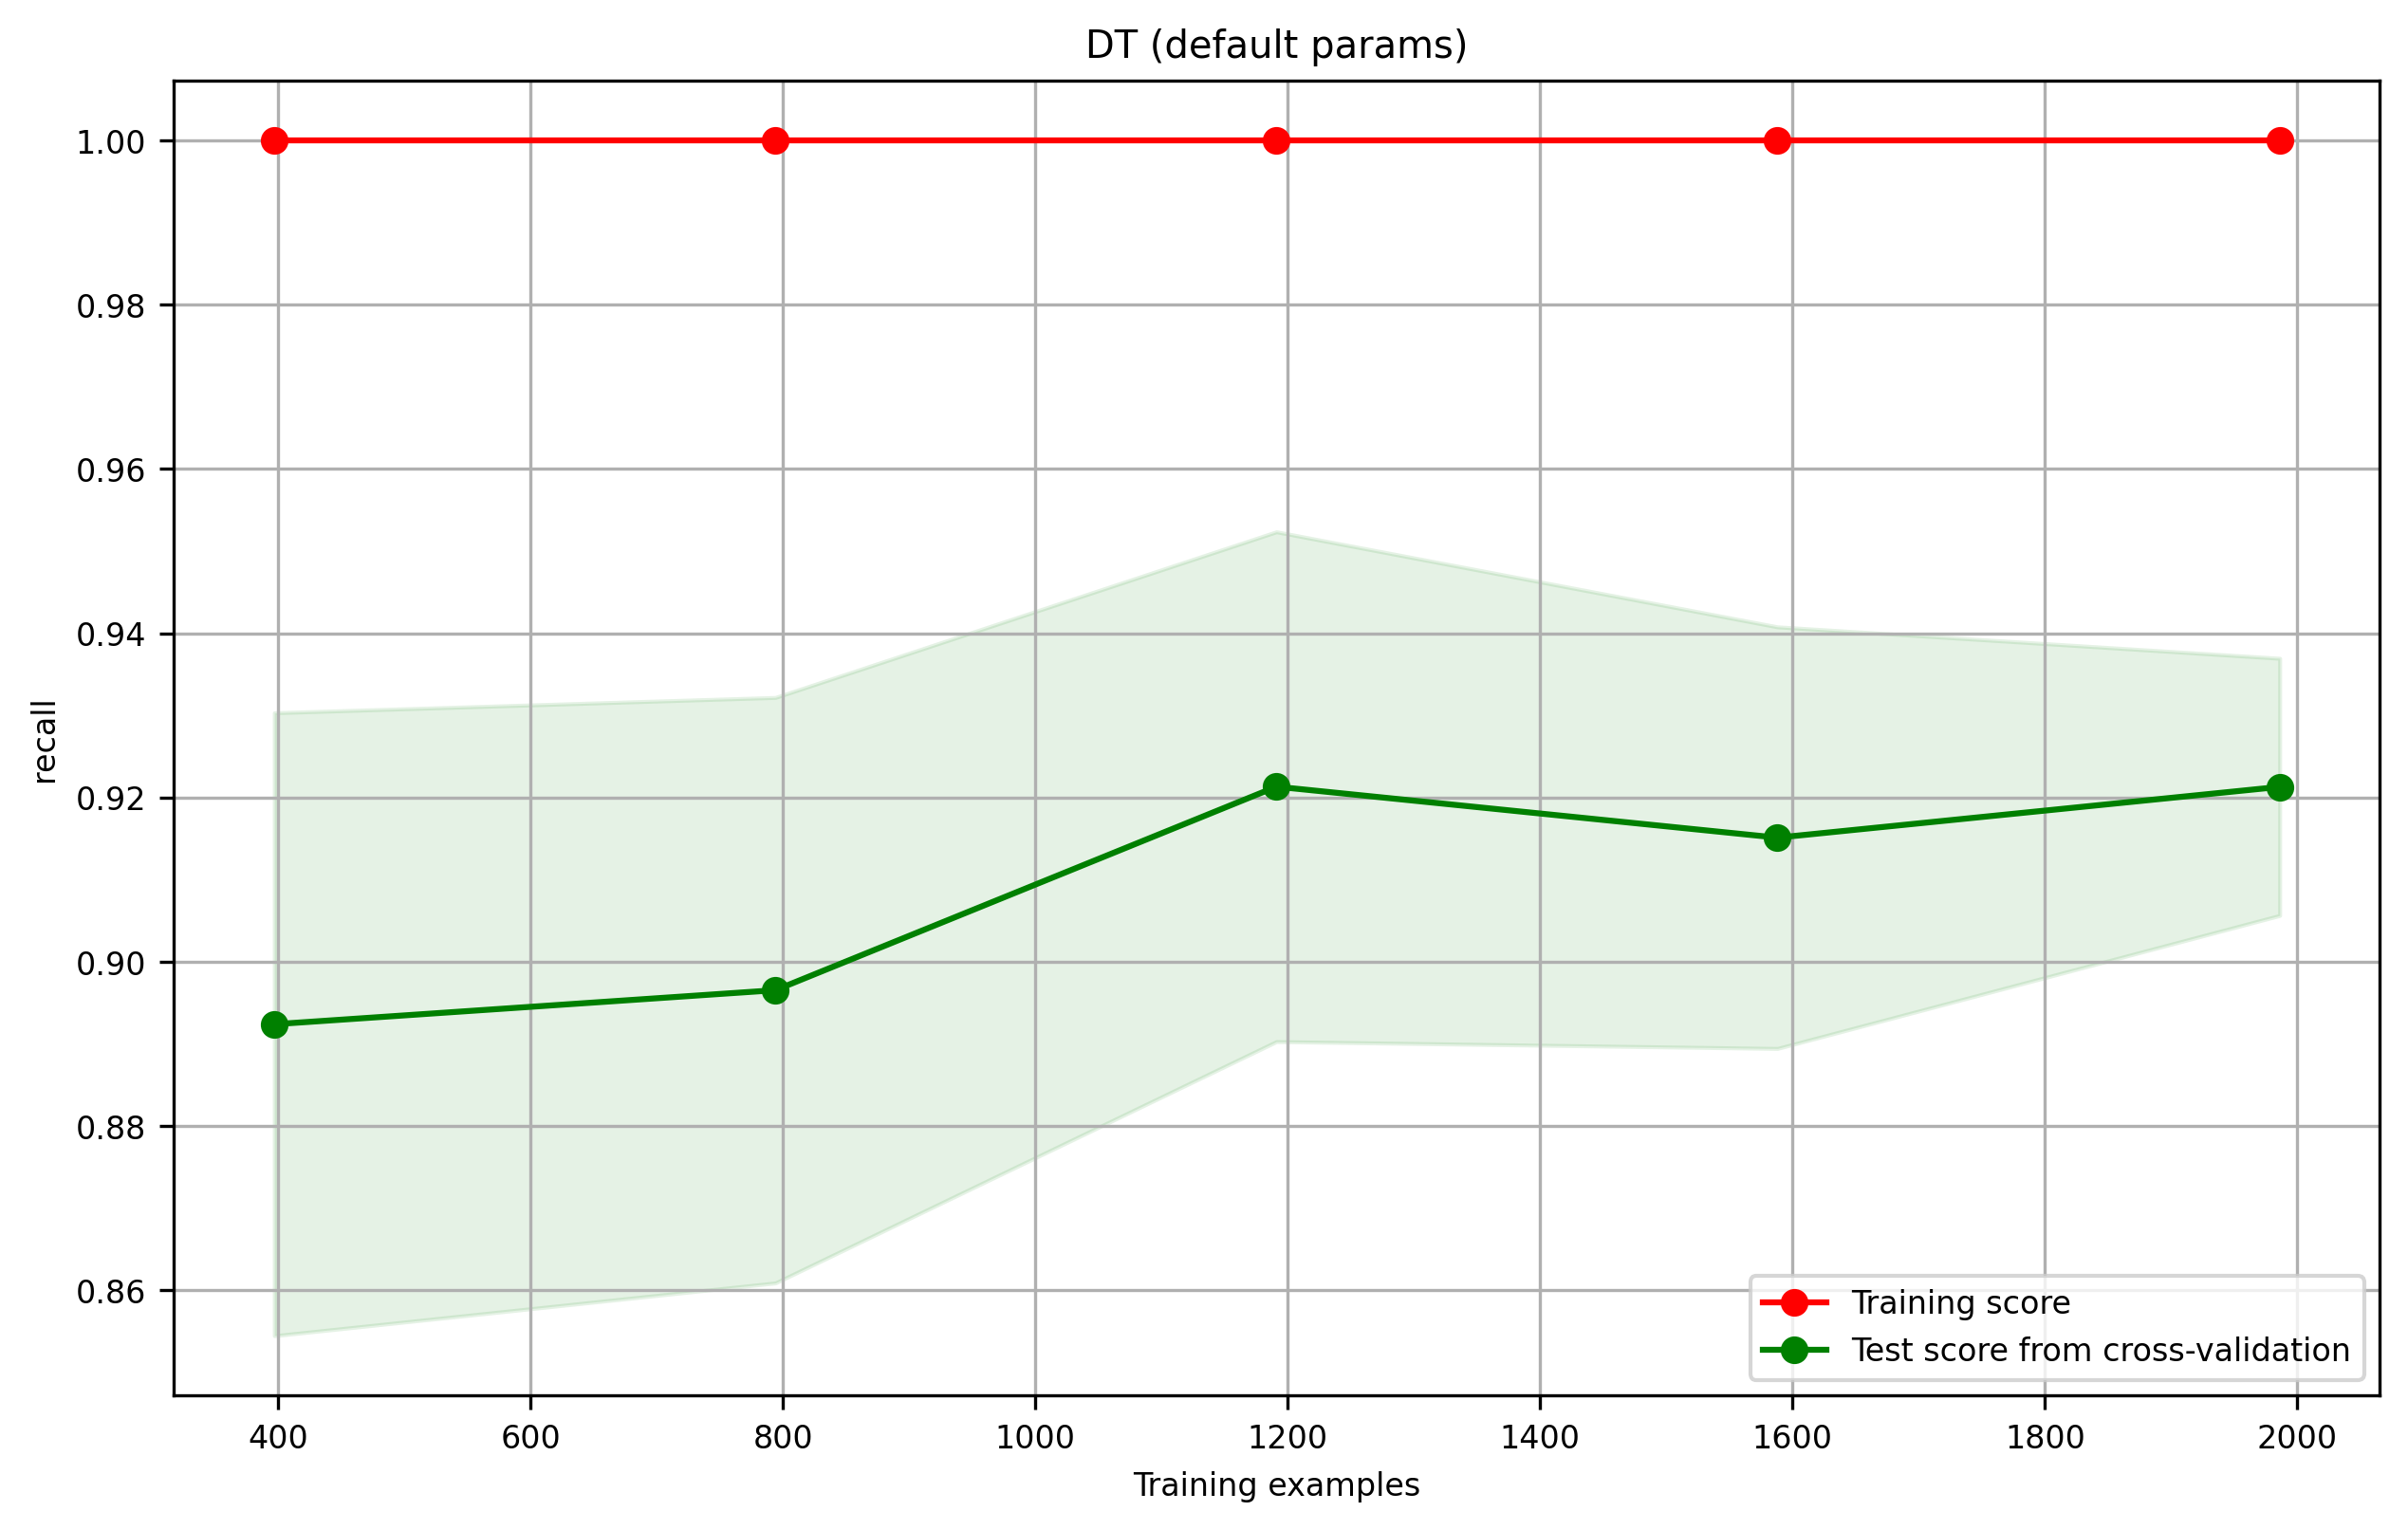

In [52]:
plot_learning_curve(model, 'DT (default params)', X, y,  cv = cv3, scoring = 'recall');

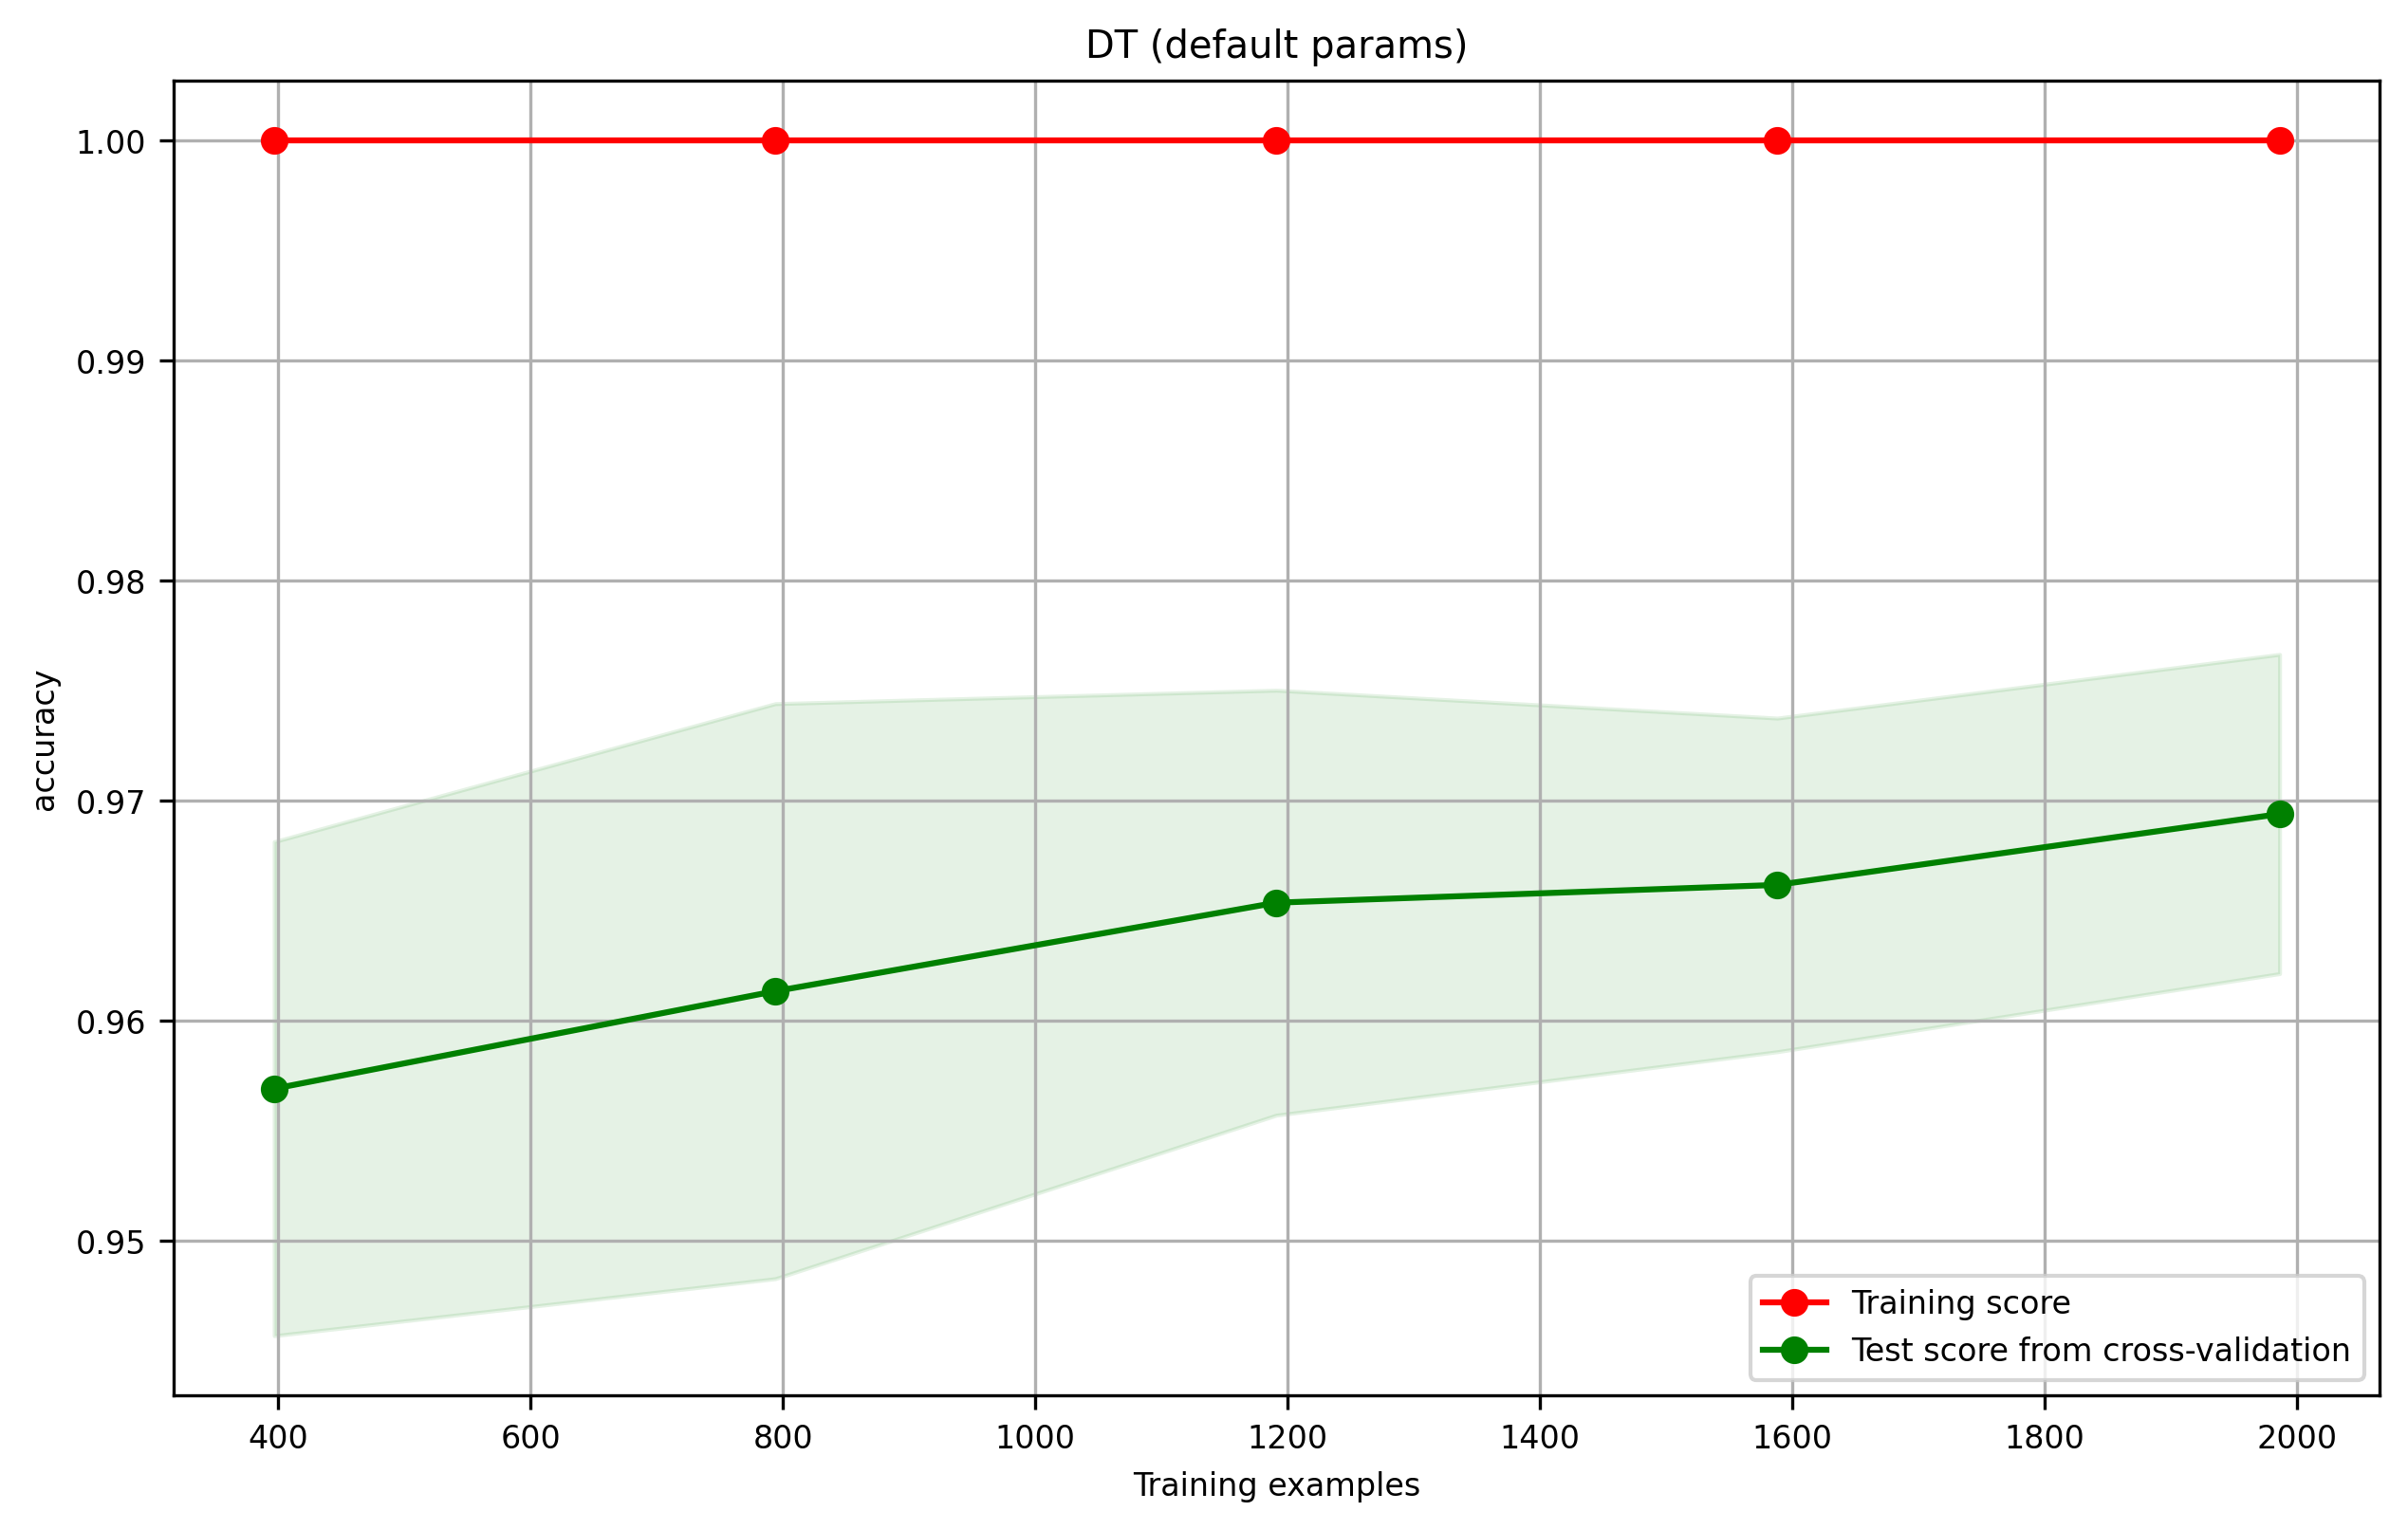

In [53]:
plot_learning_curve(model, 'DT (default params)', X, y,  cv = cv3, scoring = 'accuracy');

### **Preguntas**

Responda brevemente:

1. ¿Existe una brecha entre la curva de entrenamiento y la de validación? ¿Qué sugiere eso?
2. ¿El rendimiento de validación mejora al agregar más ejemplos?
3. ¿Hablaría aquí de alto sesgo, alta varianza o sobreajuste moderado? Justifique.
4. Escriba una conclusión general sobre el comportamiento del árbol base a partir de estas curvas.

**RESPUESTAS:**
1. Sí, existe una brecha constante. En ambas métricas el entrenamiento es perfecto (1.0), mientras que la validación se sitúa por debajo (~0.92 en recall y ~0.97 en accuracy). Esto sugiere la presencia de sobreajuste, ya que el modelo memoriza perfectamente los datos vistos pero no alcanza el mismo rendimiento con datos nuevos.
2. Sí, pero se aplana en cierto momento. En la curva de accuracy aumenta de manera sostenida desde 0.958 (en 400 ejemplos) hasta casi 0.970 (en 2000 ejemplos). En recall sube de 0.89 más o menos a poco más de 0.921, mostrándose relativamente constante a partir de los 1200 ejemplos.
3. Hablaría de sobreajuste moderado (o varianza moderada). No hay alto sesgo porque el modelo logra un rendimiento muy elevado en validación (>92\%). Tampoco es una varianza descontrolada porque la brecha no es enorme, pero el hecho de tener entrenamiento en 1.0 (practicamente perfecto) confirma que el árbol aprende de memoria los datos en el entrenamiento demasiado minuciosamente, provocando este sobreajuste en los datos de prueba.
4. El árbol de decisión con parámetros por defecto tiene una capacidad de generalización sólida pero mejorable. Aunque memoriza el set de entrenamiento completamente, se beneficia positivamente de aumentar la cantidad de datos y mantiene buenas predicciones en el set de validación, sugiriendo que limitando su profundidad (menos decisiones) se podría mejorar el modelo al eliminar el sobreajuste. 

### Desafío: ¿un árbol más simple generaliza mejor?

Entrene ahora un segundo árbol, más restringido que el árbol base. Por ejemplo, puede probar con:

- `max_depth=3`, o
- `min_samples_leaf=10`

Luego compare su rendimiento con el árbol base usando:

- accuracy
- precision
- recall
- F1-score



### Preguntas

A partir de los resultados obtenidos con validación cruzada:

1. ¿Qué ocurrió con el rendimiento al restringir la complejidad del árbol?
2. ¿El árbol más simple empeoró o mejoró la generalización?
3. ¿Qué sugieren estos resultados sobre el árbol base?
4. En este problema, ¿parece conveniente usar el árbol sin restricciones?
5. ¿Qué métrica le parece más importante para decidir entre ambos modelos?

In [59]:
# Definir y entrenar los modelos, con la restriccion max_depth = 3
dt_base = DecisionTreeClassifier(random_state=42)
dt_restringido= DecisionTreeClassifier(max_depth=3, random_state=42) 

dt_base.fit(X_train, y_train)
dt_restringido.fit(X_train, y_train)

# Se generan las predicciones
y_train_pred_base = dt_base.predict(X_train)
y_test_pred_base = dt_base.predict(X_test)

y_train_pred_restr = dt_restringido.predict(X_train)
y_test_pred_restr = dt_restringido.predict(X_test)

# Función para calcular las 4 métricas
def obtener_metricas(y_true, y_pred):
    return {
        'Accuracy': metrics.accuracy_score(y_true, y_pred),
        'Precision': metrics.precision_score(y_true, y_pred, pos_label=1),
        'Recall': metrics.recall_score(y_true, y_pred, pos_label=1),
        'F1-Score': metrics.f1_score(y_true, y_pred, pos_label=1)
    }

# Construir DataFrame comparativo
resultados = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Árbol Base (Train)': obtener_metricas(y_train, y_train_pred_base).values(),
    'Árbol Base (Test)': obtener_metricas(y_test, y_test_pred_base).values(),
    'Árbol Restringido (Train)': obtener_metricas(y_train, y_train_pred_restr).values(),
    'Árbol Restringido (Test)': obtener_metricas(y_test, y_test_pred_restr).values(),
}).set_index('Métrica')

# Mostrar resultados redondeados a 5 decimales en este caso
print("=== Comparación Árbol Base vs. Árbol Restringido ===")
resultados.round(5)

=== Comparación Árbol Base vs. Árbol Restringido ===


,Árbol Base (Train),Árbol Base (Test),Árbol Restringido (Train),Árbol Restringido (Test)
Métrica,,,,
Accuracy,1.0,0.96510,0.98446,0.97315
Precision,1.0,0.87591,0.94070,0.90370
Recall,1.0,0.93023,0.98588,0.94574
F1-Score,1.0,0.90226,0.96276,0.92424


**RESPUESTAS:**
1. En entrenamiento el rendimiento bajó ligeramente de 1.0 a ~0.98, pero en test mejoró en todas las métricas, por nombrar uno el recall en prueba subió de 0.93023 a 0.94574.
2. Mejoró la generalización. No solo achicó la brecha entre train y test, sino que además logró un mejor rendimiento sobre el conjunto de prueba que el árbol sin restricciones.
3. Confirman que el árbol base sufría de sobreajuste (overfitting), memorizando el ruido del set de entrenamiento en vez de aprender los patrones más generales que siguen los datos.
4. No es nada conveniente. El árbol restringido es superior en todas las métricas sobre datos de prueba como se puede ver en la tabla comparativa, ofrece un modelo mucho más estable y confiable.
5. El F1-Score. Al tratarse de un problema con clases desbalanceadas, resume de buena forma el balance entre precision (pureza) y Recall (completitud), confirmando la superioridad del árbol restringido (0.9242 vs. 0.9022).

## Desafío: comparar con kNN

Hasta ahora trabajamos con árboles de decisión. Ahora comparemos ese enfoque con un clasificador distinto: **k-Nearest Neighbors (kNN)**.

Entrene un modelo kNN y compárelo con el árbol simple usando validación cruzada estratificada. Recuerde que kNN está basado en distancias, por lo que antes de entrenarlo debe escalar las variables.

### Instrucciones

1. Entrene un modelo kNN con `k=5`.
2. Use un `StandardScaler` antes del clasificador.
3. Evalúe el modelo con validación cruzada estratificada usando:
   - accuracy
   - precision
   - recall
   - F1-score
4. Compare sus resultados con los del árbol simple.
5. Luego explore distintos valores de `k` y vea cómo cambian las métricas.

### Preguntas

1. ¿Cómo se compara el rendimiento de kNN con el del árbol simple?
2. ¿Qué ocurre cuando `k` es muy pequeño?
3. ¿Qué ocurre cuando `k` es muy grande?
4. ¿Qué valor de `k` parece dar el mejor equilibrio entre precision y recall?
5. ¿Qué ventaja podría tener kNN si la frontera entre clases no es rectangular?

In [60]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score

Resultados kNN (k=5) con Cross-Validation
Accuracy:  0.97756
Precision: 0.92504
Recall:    0.96893
F1-Score:  0.94624

Resultados Árbol de Decisiones Base
Accuracy:  0.96510
Precision: 0.87591
Recall:    0.93023
F1-Score:  0.90226


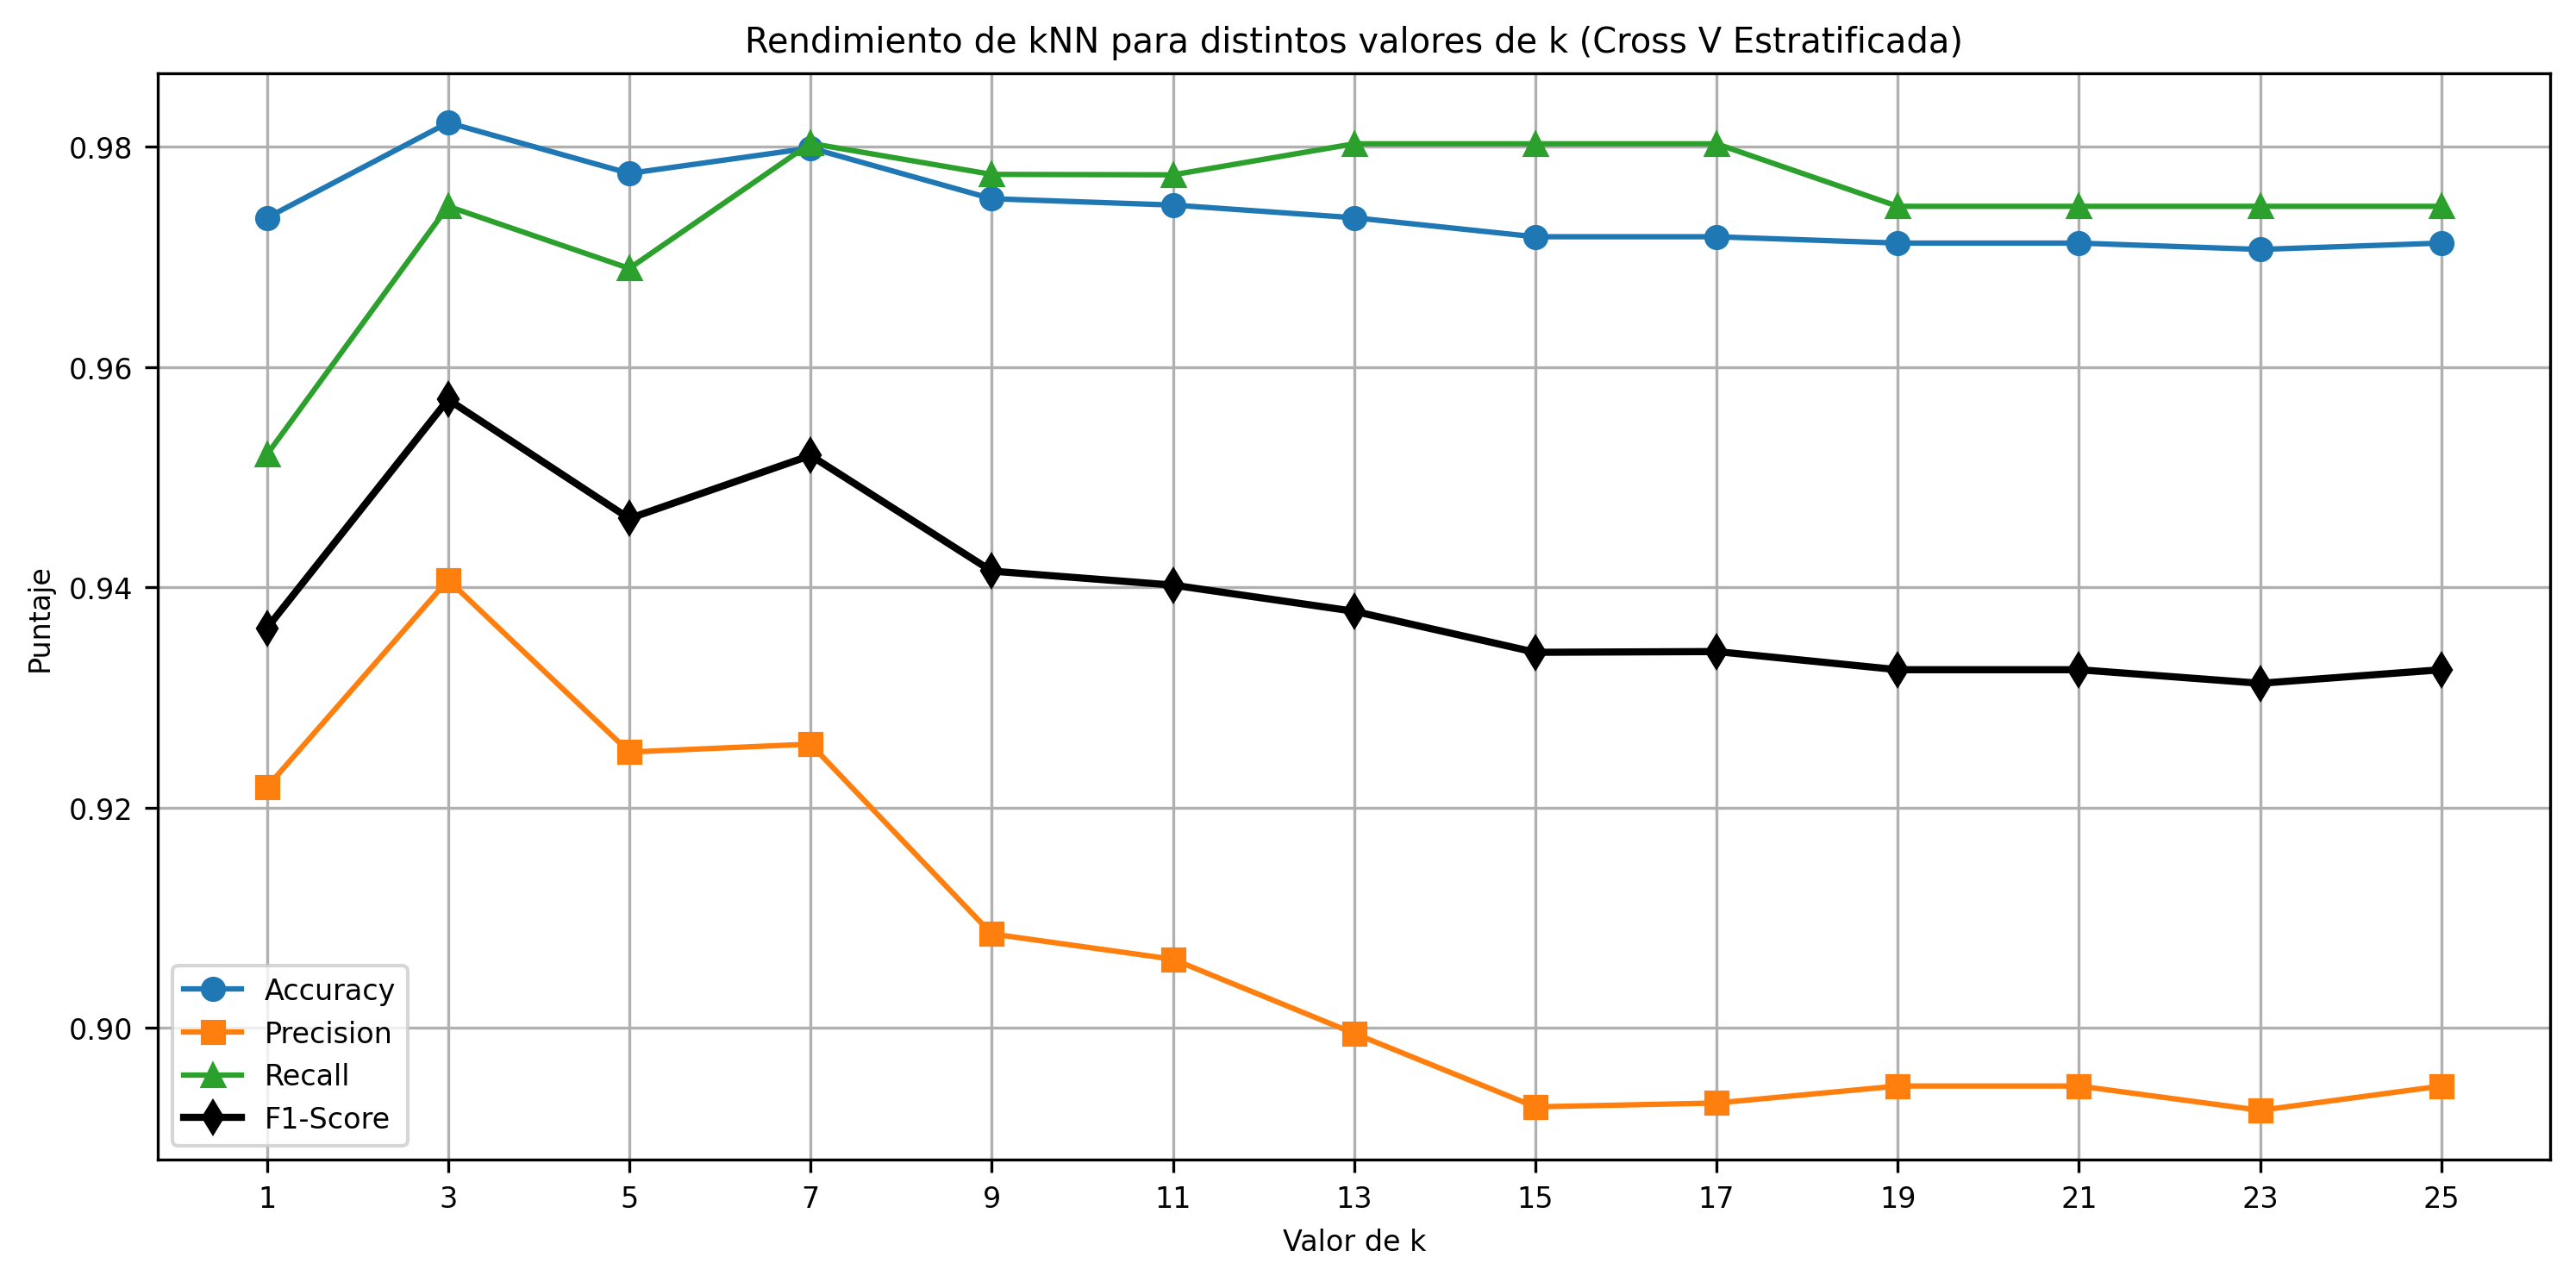

,k,Accuracy,Precision,Recall,F1-Score
0,1,0.97352,0.92185,0.95203,0.93629
1,3,0.98216,0.94067,0.97457,0.95703
2,5,0.97756,0.92504,0.96893,0.94624
3,7,0.97986,0.92576,0.98028,0.95196
4,9,0.97526,0.90854,0.97746,0.94147
5,11,0.97468,0.90624,0.97742,0.94020
6,13,0.97353,0.89952,0.98024,0.93782
7,15,0.97181,0.89285,0.98024,0.93410
8,17,0.97181,0.89319,0.98024,0.93416
9,19,0.97123,0.89474,0.97457,0.93252


In [68]:
# Definir la etiqueta positiva (ajusta a 'RR Lyrae' o 1 según tus datos)
POS_LABEL = 'RR Lyrae' 

# Configurar Validación Cruzada Estratificada (5 Folds)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Métricas para cross_validate con el pos_label correcto
scorers = {
    'accuracy': 'accuracy',
    'precision': make_scorer(precision_score, pos_label=1, zero_division=0),
    'recall': make_scorer(recall_score, pos_label=1, zero_division=0),
    'f1': make_scorer(f1_score, pos_label=1, zero_division=0)
}

# Pipeline kNN con k=5 y Escalado
knn_pipe_5 = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])

# Evaluar k=5 con Cross-Validation
cv_k5 = cross_validate(knn_pipe_5, X_train, y_train, cv=skf, scoring=scorers)

print("Resultados kNN (k=5) con Cross-Validation")
print(f"Accuracy:  {cv_k5['test_accuracy'].mean():.5f}")
print(f"Precision: {cv_k5['test_precision'].mean():.5f}")
print(f"Recall:    {cv_k5['test_recall'].mean():.5f}")
print(f"F1-Score:  {cv_k5['test_f1'].mean():.5f}\n")

# Mostrar los resultados obtenidos para el Arbol Base
print("Resultados Árbol de Decisiones Base")
print(f"Accuracy:  {metrics.accuracy_score(y_test, y_pred):.5f}")
print(f"Precision: {metrics.precision_score(y_test, y_pred):.5f}")
print(f"Recall:    {metrics.recall_score(y_test, y_pred):.5f}")
print(f"F1-Score:  {metrics.f1_score(y_test, y_pred):.5f}")

# Exploración de distintos valores de k (impares del 1 al 25)
k_values = list(range(1, 26, 2))
results = []

for k in k_values:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=k))
    ])
    cv_res = cross_validate(pipe, X_train, y_train, cv=skf, scoring=scorers)
    results.append({
        'k': k,
        'Accuracy': cv_res['test_accuracy'].mean(),
        'Precision': cv_res['test_precision'].mean(),
        'Recall': cv_res['test_recall'].mean(),
        'F1-Score': cv_res['test_f1'].mean()
    })

df_k = pd.DataFrame(results)

# Graficar comportamiento según k
plt.figure(figsize=(10, 5))
plt.plot(df_k['k'], df_k['Accuracy'], label='Accuracy', marker='o')
plt.plot(df_k['k'], df_k['Precision'], label='Precision', marker='s')
plt.plot(df_k['k'], df_k['Recall'], label='Recall', marker='^')
plt.plot(df_k['k'], df_k['F1-Score'], label='F1-Score', marker='d', linewidth=2, color='black')

plt.title('Rendimiento de kNN para distintos valores de k (Cross V Estratificada)')
plt.xlabel('Valor de k')
plt.ylabel('Puntaje')
plt.xticks(k_values)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Mostrar tabla con resultados por k
df_k.round(5)

**RESPUESTAS:**
1. kNN al igual que el arbol restringido supera claramente al árbol de decisión en todas las métricas (F1 de 0.9462 frente a 0.9022 en k=5). Al escalar las variables y evaluar distancias geométricas (método k-nn), el modelo logra capturar mejor la estructura y comportamiento de los datos.
2. Con k=1, el modelo se vuelve muy sensible al ruido local y a valores atípicos (tendencia al sobreajuste). Esto provoca que la precisión y el recall sean un poco más bajos que para el resto de k's (un vecindario ligeramente mayor).
3. Con un k elevado (k > 13), la precisión cae de forma sostenida (baja a ~ 0.89 y se mantiene). El modelo suaviza en exceso la frontera y se sesga hacia la clase mayoritaria, en otras palabras el modelo tienen a subajustarse y termina deteriorando el F1 score general.
4. En k = 3 se obtiene el mejor desempeño global, alcanzando el pico de F1 score (0.9570), una precisión máxima de 0.9407 y un alto recall de 0.9746, el balance es muy bueno.
5. Los árboles dividen el espacio mediante cortes perpendiculares a los ejes. En cambio kNN, al basarse en distancias continuas, puede moldear fronteras diagonales, curvas o complejas de forma mucho más suave y realista, obteniendo los mejores resultados (con k = 3) y siendo más robusto que ambos árboles de decisiones.

## Cierre

En esta actividad vimos que evaluar un clasificador no consiste solo en obtener un score alto, sino en interpretar qué está midiendo cada métrica y cómo se construyen los conjuntos de validación. En este problema, el uso de validación cruzada estratificada fue importante para obtener una evaluación más estable y representativa.

También observamos que un modelo más complejo no siempre generaliza mejor. Aunque el árbol base ajustaba perfectamente los datos de entrenamiento, un árbol más simple logró mejores resultados en validación cruzada, lo que sugiere que reducir la complejidad ayudó a disminuir el sobreajuste.